In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("application_train.csv")

print("Shape:", df.shape)

display(
    pd.DataFrame({
        "Count": df["TARGET"].value_counts(),
        "Percentage": round(
            df["TARGET"].value_counts(normalize=True)*100,
            2
        )
    })
)

Shape: (307511, 122)


,Count,Percentage
TARGET,,
0,282686,91.93
1,24825,8.07


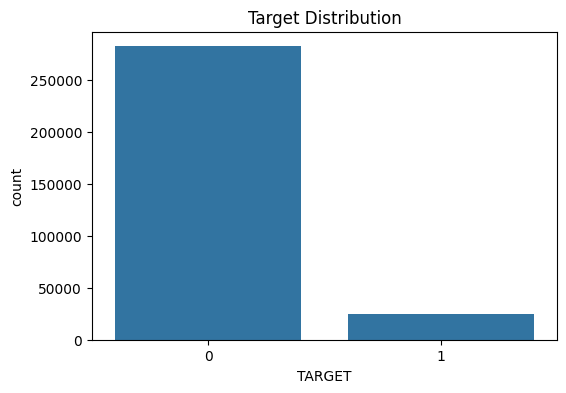

In [167]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="TARGET",
    data=df
)

plt.title("Target Distribution")
plt.show()

In [168]:
missing = pd.DataFrame({
    "Missing_Percent":
    round(
        df.isnull().mean()*100,
        2
    )
})

missing = missing[
    missing["Missing_Percent"] > 0
]

missing.sort_values(
    "Missing_Percent",
    ascending=False
).head(20)

,Missing_Percent
COMMONAREA_AVG,69.87
COMMONAREA_MODE,69.87
COMMONAREA_MEDI,69.87
NONLIVINGAPARTMENTS_MODE,69.43
NONLIVINGAPARTMENTS_AVG,69.43
NONLIVINGAPARTMENTS_MEDI,69.43
FONDKAPREMONT_MODE,68.39
LIVINGAPARTMENTS_MODE,68.35
LIVINGAPARTMENTS_MEDI,68.35
LIVINGAPARTMENTS_AVG,68.35


In [ ]:

df["AGE"] = (
    abs(df["DAYS_BIRTH"]) / 365
)

# HANDLE INVALID EMPLOYMENT VALUE

df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(
    365243,
    np.nan
)

# EMPLOYMENT YEARS

df["YEARS_EMPLOYED"] = (
    abs(df["DAYS_EMPLOYED"]) / 365
)

# CREDIT BURDEN

df["CREDIT_INCOME_RATIO"] = (
    df["AMT_CREDIT"] /
    df["AMT_INCOME_TOTAL"]
)

# MONTHLY PAYMENT BURDEN

df["ANNUITY_INCOME_RATIO"] = (
    df["AMT_ANNUITY"] /
    df["AMT_INCOME_TOTAL"]
)

# QUICK CHECK

feature_cols = [
    "AGE",
    "YEARS_EMPLOYED",
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO"
]

df[feature_cols].describe()

,AGE,YEARS_EMPLOYED,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO
count,307511.000000,252137.000000,307511.000000,307499.000000
mean,43.936973,6.531971,3.957570,0.180930
std,11.956133,6.406466,2.689728,0.094574
min,20.517808,0.000000,0.004808,0.000224
25%,34.008219,2.101370,2.018667,0.114782
50%,43.150685,4.515068,3.265067,0.162833
75%,53.923288,8.698630,5.159880,0.229067
max,69.120548,49.073973,84.736842,1.875965


In [170]:
missing_pct = (
    df.isnull()
      .mean()
      .sort_values(ascending=False)
      * 100
)

missing_pct.head(20)

COMMONAREA_MEDI             69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_AVG              69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_MODE       68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_AVG        68.354953
FLOORSMIN_MEDI              67.848630
FLOORSMIN_MODE              67.848630
FLOORSMIN_AVG               67.848630
YEARS_BUILD_MEDI            66.497784
YEARS_BUILD_AVG             66.497784
YEARS_BUILD_MODE            66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_AVG                59.376738
LANDAREA_MEDI               59.376738
LANDAREA_MODE               59.376738
dtype: float64

In [171]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
bureau = pd.read_csv(
    "bureau.csv"
)

print(bureau.shape)

bureau.head()

(1716428, 17)


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [174]:
bureau_features = bureau.groupby(
    "SK_ID_CURR"
).agg({

    "AMT_CREDIT_SUM": [
        "sum",
        "mean"
    ],

    "AMT_CREDIT_SUM_DEBT": [
        "sum",
        "mean"
    ],

    "DAYS_CREDIT": [
        "min",
        "max",
        "mean"
    ]

}).reset_index()

In [175]:
bureau_features.columns = [

    "SK_ID_CURR",

    "TOTAL_CREDIT_SUM",
    "AVG_CREDIT_SUM",

    "TOTAL_DEBT",
    "AVG_DEBT",

    "OLDEST_CREDIT",
    "NEWEST_CREDIT",
    "AVG_CREDIT_AGE"

]

In [176]:
active_loans = (
    bureau[
        bureau["CREDIT_ACTIVE"] == "Active"
    ]
    .groupby("SK_ID_CURR")
    .size()
    .reset_index(name="ACTIVE_LOAN_COUNT")
)

In [177]:
closed_loans = (
    bureau[
        bureau["CREDIT_ACTIVE"] == "Closed"
    ]
    .groupby("SK_ID_CURR")
    .size()
    .reset_index(name="CLOSED_LOAN_COUNT")
)

In [178]:
bureau_features = bureau_features.merge(
    active_loans,
    on="SK_ID_CURR",
    how="left"
)

bureau_features = bureau_features.merge(
    closed_loans,
    on="SK_ID_CURR",
    how="left"
)

In [179]:
bureau_features[
    [
        "ACTIVE_LOAN_COUNT",
        "CLOSED_LOAN_COUNT"
    ]
] = bureau_features[
    [
        "ACTIVE_LOAN_COUNT",
        "CLOSED_LOAN_COUNT"
    ]
].fillna(0)

In [180]:
df = pd.read_csv(
    "application_train.csv"
)

In [181]:
df = df.merge(
    bureau_features,
    on="SK_ID_CURR",
    how="left"
)

In [182]:
new_cols = [
    "TOTAL_CREDIT_SUM",
    "AVG_CREDIT_SUM",
    "TOTAL_DEBT",
    "AVG_DEBT",
    "ACTIVE_LOAN_COUNT",
    "CLOSED_LOAN_COUNT"
]

df[new_cols].describe()

,TOTAL_CREDIT_SUM,AVG_CREDIT_SUM,TOTAL_DEBT,AVG_DEBT,ACTIVE_LOAN_COUNT,CLOSED_LOAN_COUNT
count,2.634910e+05,2.634900e+05,2.634910e+05,2.561310e+05,263491.000000,263491.000000
mean,1.955807e+06,3.780802e+05,6.406503e+05,1.603901e+05,2.056689,3.482977
std,4.101728e+06,8.916731e+05,1.633961e+06,5.266501e+05,1.787834,3.381632
min,0.000000e+00,0.000000e+00,-6.981558e+06,-1.083615e+06,0.000000,0.000000
25%,3.433773e+05,1.035000e+05,0.000000e+00,0.000000e+00,1.000000,1.000000
50%,9.617040e+05,1.955072e+05,1.690200e+05,4.420804e+04,2.000000,3.000000
75%,2.297721e+06,3.941162e+05,6.600621e+05,1.421362e+05,3.000000,5.000000
max,1.017958e+09,1.980723e+08,3.344983e+08,4.365000e+07,32.000000,108.000000


In [183]:
bureau[
    bureau["AMT_CREDIT_SUM_DEBT"] < 0
][
    [
        "AMT_CREDIT_SUM_DEBT",
        "CREDIT_ACTIVE",
        "CREDIT_TYPE"
    ]
].head(20)

,AMT_CREDIT_SUM_DEBT,CREDIT_ACTIVE,CREDIT_TYPE
21,-411.615,Active,Credit card
87,-2692.170,Closed,Credit card
88,-149.040,Closed,Credit card
89,-2.565,Active,Credit card
125,-701.280,Closed,Credit card
166,-45.360,Active,Credit card
225,-638.100,Active,Credit card
236,-15.255,Closed,Credit card
297,-455.805,Closed,Credit card
300,-45.000,Active,Credit card


In [184]:
bureau["AMT_CREDIT_SUM_DEBT"] = (
    bureau["AMT_CREDIT_SUM_DEBT"]
    .clip(lower=0)
)

In [185]:
prev = pd.read_csv(
    "previous_application.csv"
)

print(prev.shape)

prev.head()

(1670214, 37)


,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [186]:
prev_app_count = (
    prev.groupby("SK_ID_CURR")
        .size()
        .reset_index(name="PREV_APP_COUNT")
)

In [187]:
approved = (
    prev[
        prev["NAME_CONTRACT_STATUS"] == "Approved"
    ]
    .groupby("SK_ID_CURR")
    .size()
    .reset_index(name="APPROVED_COUNT")
)

In [188]:
refused = (
    prev[
        prev["NAME_CONTRACT_STATUS"] == "Refused"
    ]
    .groupby("SK_ID_CURR")
    .size()
    .reset_index(name="REFUSED_COUNT")
)

In [189]:
loan_stats = (
    prev.groupby("SK_ID_CURR")
        .agg({
            "AMT_CREDIT": [
                "mean",
                "max"
            ],

            "AMT_ANNUITY": [
                "mean"
            ],

            "AMT_APPLICATION": [
                "mean"
            ],

            "DAYS_DECISION": [
                "max"
            ]
        })
        .reset_index()
)

In [190]:
loan_stats.columns = [

    "SK_ID_CURR",

    "AVG_PREV_CREDIT",
    "MAX_PREV_CREDIT",

    "AVG_PREV_ANNUITY",

    "AVG_PREV_APPLICATION",

    "LAST_DECISION_DAY"
]

In [191]:
prev_features = loan_stats.merge(
    prev_app_count,
    on="SK_ID_CURR",
    how="left"
)

prev_features = prev_features.merge(
    approved,
    on="SK_ID_CURR",
    how="left"
)

prev_features = prev_features.merge(
    refused,
    on="SK_ID_CURR",
    how="left"
)

In [192]:
prev_features[
    [
        "PREV_APP_COUNT",
        "APPROVED_COUNT",
        "REFUSED_COUNT"
    ]
] = prev_features[
    [
        "PREV_APP_COUNT",
        "APPROVED_COUNT",
        "REFUSED_COUNT"
    ]
].fillna(0)

In [193]:
prev_features["APPROVAL_RATE"] = (
    prev_features["APPROVED_COUNT"]
    /
    prev_features["PREV_APP_COUNT"]
)

In [194]:
prev_features["APPROVAL_RATE"] = (
    prev_features["APPROVAL_RATE"]
    .fillna(0)
)

In [195]:
prev_features["YEARS_SINCE_LAST_APPLICATION"] = (
    abs(prev_features["LAST_DECISION_DAY"]) / 365
)

In [196]:
df = df.merge(
    prev_features,
    on="SK_ID_CURR",
    how="left"
)

In [197]:
df.drop(
    columns=["LAST_DECISION_DAY"],
    inplace=True
)

In [198]:
installments = pd.read_csv(
    "installments_payments.csv"
)

print(installments.shape)

installments.head()

(13605401, 8)


,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


In [199]:
installments["DAYS_LATE"] = (
    installments["DAYS_ENTRY_PAYMENT"]
    -
    installments["DAYS_INSTALMENT"]
)

installments["LATE_FLAG"] = (
    installments["DAYS_LATE"] > 0
).astype(int)

installments["PAYMENT_RATIO"] = (
    installments["AMT_PAYMENT"]
    /
    installments["AMT_INSTALMENT"]
)

In [200]:
import numpy as np

installments["PAYMENT_RATIO"] = np.where(
    installments["AMT_INSTALMENT"] > 0,
    installments["AMT_PAYMENT"] / installments["AMT_INSTALMENT"],
    np.nan
)

In [201]:
installments["PAYMENT_RATIO"] = (
    installments["PAYMENT_RATIO"]
    .clip(upper=5)
)

In [202]:
inst_features = (
    installments.groupby("SK_ID_CURR")
    .agg({
        "DAYS_LATE": ["mean", "max"],
        "LATE_FLAG": ["sum", "mean"],
        "PAYMENT_RATIO": ["mean"],
        "AMT_PAYMENT": ["sum"]
    })
    .reset_index()
)

In [203]:
inst_features.columns = [
    "SK_ID_CURR",
    "AVG_DAYS_LATE",
    "MAX_DAYS_LATE",
    "LATE_PAYMENT_COUNT",
    "LATE_PAYMENT_RATE",
    "AVG_PAYMENT_RATIO",
    "TOTAL_PAYMENT"
]

In [213]:
df = df.merge(
    inst_features,
    on="SK_ID_CURR",
    how="left"
)

print(df.shape)

(307511, 152)


In [216]:
drop_cols = [
    "AVG_DAYS_LATE_y",
    "MAX_DAYS_LATE_y",
    "LATE_PAYMENT_COUNT_y",
    "LATE_PAYMENT_RATE_y",
    "AVG_PAYMENT_RATIO_y",
    "TOTAL_PAYMENT_y"
]

df.drop(columns=drop_cols, inplace=True)

In [217]:
df.rename(
    columns={
        "AVG_DAYS_LATE_x":"AVG_DAYS_LATE",
        "MAX_DAYS_LATE_x":"MAX_DAYS_LATE",
        "LATE_PAYMENT_COUNT_x":"LATE_PAYMENT_COUNT",
        "LATE_PAYMENT_RATE_x":"LATE_PAYMENT_RATE",
        "AVG_PAYMENT_RATIO_x":"AVG_PAYMENT_RATIO",
        "TOTAL_PAYMENT_x":"TOTAL_PAYMENT"
    },
    inplace=True
)

In [220]:
X = df.drop(columns=["TARGET"])

y = df["TARGET"]

In [233]:
X.isnull().sum().sum()

9035373

In [248]:
for col in X.columns:
    if X[col].dtype in ["int64","float64"]:
        X[col] = X[col].fillna(X[col].median())
    else:
        X[col] = X[col].fillna(X[col].mode()[0])

In [235]:
print(X.isnull().sum().sum())

0


In [236]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(246008, 145)
(61503, 145)


In [247]:
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=10,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

y_prob_xgb = xgb.predict_proba(X_test)[:,1]

roc_xgb = roc_auc_score(
    y_test,
    y_prob_xgb
)

print("XGBoost:", roc_xgb)

XGBoost: 0.7734089794146775


In [238]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42
)

lgbm.fit(X_train, y_train)

y_prob_lgbm = lgbm.predict_proba(X_test)[:,1]

roc_lgbm = roc_auc_score(
    y_test,
    y_prob_lgbm
)

print("LightGBM:", roc_lgbm)

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.152403 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 16240
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 141
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
LightGBM: 0.7731934571752168


In [239]:
from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    verbose=0,
    random_state=42
)

cat.fit(X_train, y_train)

y_prob_cat = cat.predict_proba(X_test)[:,1]

roc_cat = roc_auc_score(
    y_test,
    y_prob_cat
)

print("CatBoost:", roc_cat)

CatBoost: 0.773589020344292


In [242]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_prob_rf = rf.predict_proba(X_test)[:,1]

roc_rf = roc_auc_score(
    y_test,
    y_prob_rf
)

print("RF:", roc_rf)

RF: 0.7277666613694069


In [243]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

lr = LogisticRegression(
    max_iter=2000,
    n_jobs=-1
)

lr.fit(X_train, y_train)

y_prob_lr = lr.predict_proba(X_test)[:,1]

roc_lr = roc_auc_score(
    y_test,
    y_prob_lr
)

print("Logistic:", roc_lr)

Logistic: 0.6491165421026888


In [246]:
results = pd.DataFrame({
    "Model":[
        "Logistic",
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ],
    "ROC_AUC":[
        roc_lr,
        roc_xgb,
        roc_lgbm,
        roc_cat
    ]
})

results.sort_values(
    "ROC_AUC",
    ascending=False
).reset_index(drop=True)

,Model,ROC_AUC
0,CatBoost,0.773589
1,XGBoost,0.773409
2,LightGBM,0.773193
3,Logistic,0.649117


In [249]:
y_prob = cat.predict_proba(X_test)[:,1]

In [254]:
results = []

for threshold in [i/100 for i in range(5,96,5)]:

    y_pred = (y_prob >= threshold).astype(int)

    results.append([
        threshold,
        precision_score(y_test,y_pred),
        recall_score(y_test,y_pred),
        f1_score(y_test,y_pred)
    ])

threshold_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1"
    ]
)

threshold_df
threshold_df.sort_values(
    "F1",
    ascending=False
)

c:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

,Threshold,Precision,Recall,F1
2,0.15,0.255344,0.435448,0.321918
3,0.20,0.313778,0.305942,0.309810
1,0.10,0.200039,0.624169,0.302977
4,0.25,0.366745,0.220342,0.275289
0,0.05,0.131488,0.852568,0.227838
5,0.30,0.422481,0.153676,0.225373
6,0.35,0.478142,0.105740,0.173182
7,0.40,0.516667,0.068681,0.121244
8,0.45,0.560197,0.045921,0.084885
9,0.50,0.634043,0.030010,0.057308


In [255]:
from sklearn.metrics import classification_report

y_pred = (y_prob >= 0.15).astype(int)

print(
    classification_report(
        y_test,
        y_pred,
        digits=3
    )
)

              precision    recall  f1-score   support

           0      0.947     0.888     0.917     56538
           1      0.255     0.435     0.322      4965

    accuracy                          0.852     61503
   macro avg      0.601     0.662     0.619     61503
weighted avg      0.891     0.852     0.869     61503



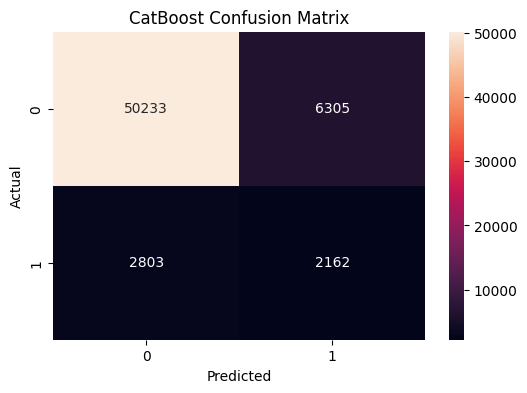

In [256]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("CatBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [258]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": cat.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
41,EXT_SOURCE_2,15.062391
42,EXT_SOURCE_3,14.537459
40,EXT_SOURCE_1,6.934982
16,DAYS_BIRTH,4.035304
9,AMT_GOODS_PRICE,3.004036
7,AMT_CREDIT,2.896326
142,LATE_PAYMENT_RATE,2.730513
2,CODE_GENDER,2.629745
12,NAME_EDUCATION_TYPE,2.417050
144,TOTAL_PAYMENT,2.404013


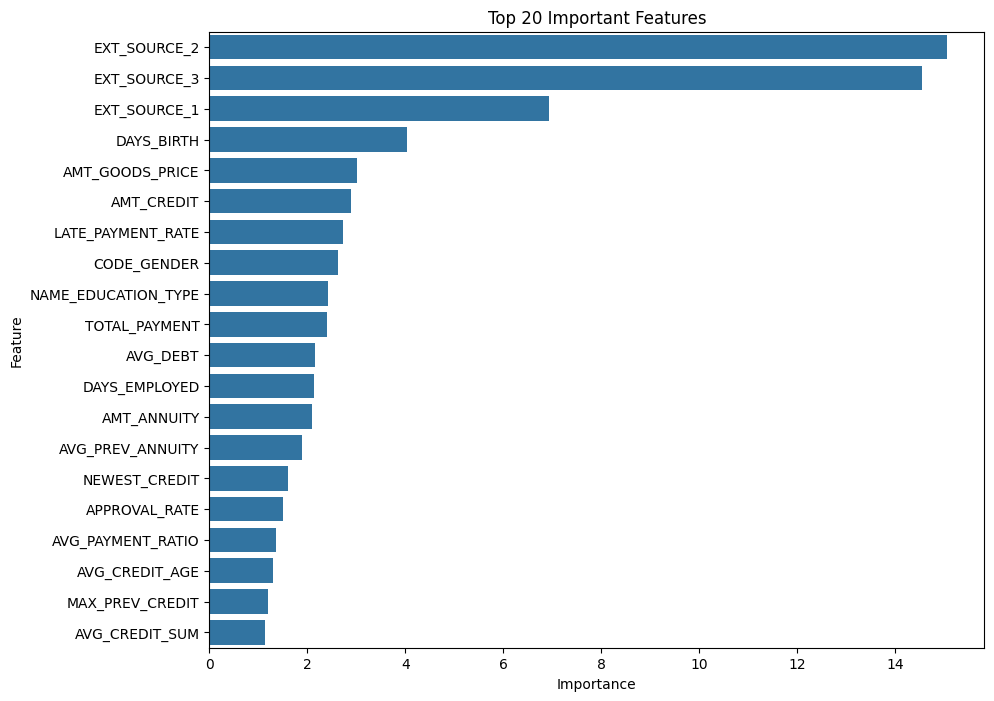

In [259]:
top20 = importance.head(20)

plt.figure(figsize=(10,8))

sns.barplot(
    data=top20,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 20 Important Features"
)

plt.show()

In [260]:
pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [261]:
import shap

explainer = shap.TreeExplainer(cat)

shap_values = explainer.shap_values(X_test)

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


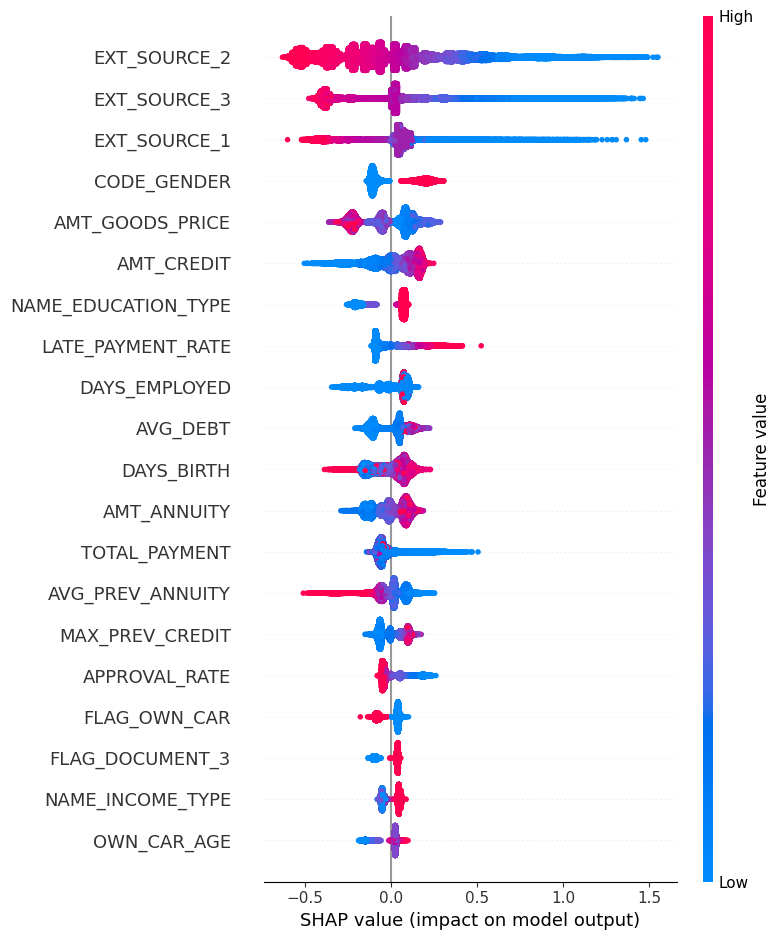

In [262]:
shap.summary_plot(
    shap_values,
    X_test
)

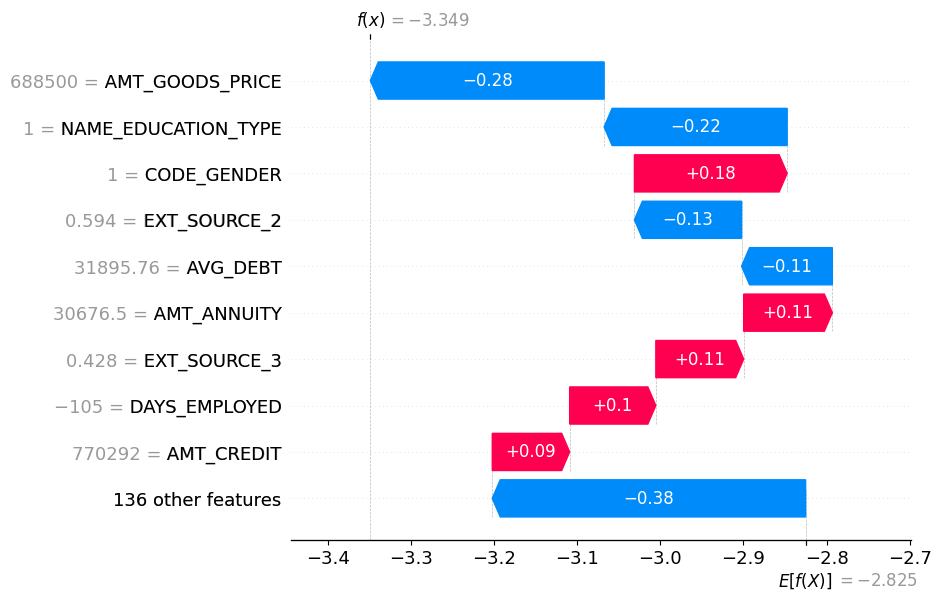

In [263]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test.iloc[0],
        feature_names=X_test.columns
    )
)

In [264]:
import joblib

joblib.dump(
    cat,
    "catboost_credit_risk.pkl"
)

['catboost_credit_risk.pkl']

In [265]:
joblib.dump(
    list(X.columns),
    "feature_columns.pkl"
)

['feature_columns.pkl']

In [266]:
THRESHOLD = 0.15